In [1]:
pip install pandas numpy matplotlib scipy



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 1. Carga de datos

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Conectar a la base de datos del script maestro
conn = sqlite3.connect("eurostat/eurostat_data/eurostat_convergencia.db")

# Cargar TODO lo que tengas (UE14 + V4 + cualquier otro país que hayas descargado)
df = pd.read_sql_query(
    "SELECT pais, año, valor FROM convergencia ORDER BY pais, año", 
    conn
)

conn.close()

print(f"Registros: {len(df)} | Países: {df['pais'].nunique()} | Años: {df['año'].min()}-{df['año'].max()}")

Registros: 356 | Países: 18 | Años: 2004-2023


# 2. Definicion de Grupos

In [3]:

# ========== 2. DEFINIR GRUPOS Y CALCULAR PROMEDIOS ==========

UE14 = ["AT", "BE", "DK", "FI", "FR", "DE", "EL", "IE", "IT", "LU", "NL", "PT", "ES", "SE"]
V4 = ["PL", "CZ", "HU", "SK"]

# Promedio UE-14 por año
promedio_ue14 = df[df["pais"].isin(UE14)].groupby("año")["valor"].mean()

# Crear matriz de datos para V4
v4_data = {}
for pais in V4:
    v4_data[pais] = df[df["pais"] == pais].set_index("año")["valor"].sort_index()

print("=" * 70)
print("2. GRUPOS DEFINIDOS")
print("=" * 70)
print(f"UE-14: {len(UE14)} países")
print(f"V4: {V4}")
print(f"\nPromedio UE-14 en 2004: {promedio_ue14.iloc[0]:,.0f} PPS")
print(f"Promedio UE-14 en 2023: {promedio_ue14.iloc[-1]:,.0f} PPS")
print(f"\nPIB per cápita V4 en 2004:")
for pais in V4:
    print(f"   {pais}: {v4_data[pais].iloc[0]:,.0f} PPS")


2. GRUPOS DEFINIDOS
UE-14: 14 países
V4: ['PL', 'CZ', 'HU', 'SK']

Promedio UE-14 en 2004: 27,214 PPS
Promedio UE-14 en 2023: 47,449 PPS

PIB per cápita V4 en 2004:
   PL: 10,962 PPS
   CZ: 17,135 PPS
   HU: 13,280 PPS
   SK: 12,370 PPS


## Reflexiones
Necesitamos analizar el bloque UE14 de acuerdo a la proporcion de peso de las economias que lo integran. Un promedio aritmetico es engañoso. Un promedio ponderado por población sería más representativo de la "experiencia económica promedio" del ciudadano de la UE-14.


- Opción A: Stacked area chart
    Eje X: años
    Eje Y: PIBpc acumulado o proporción del total
    Cada país es una capa de color
    Se ve quién "jala" el promedio hacia arriba o abajo

- Opción B: Small multiples
    Un mini-gráfico de línea por país
    Todos con la misma escala Y
    Se ve claramente quién está por encima/del promedio

- Opción C: Desviación del promedio
    Para cada país: (PIBpc país - promedio UE14) / promedio UE14
    Barras positivas/negativas por año
    Se ve quién aporta positiva o negativamente


In [27]:
# Promedio Ponderado




# 3. Índice de convergencia

In [4]:

# ========== 3. ÍNDICE DE CONVERGENCIA ==========
# (PIBpc país / PIBpc UE-14) × 100

convergencia = pd.DataFrame()
for pais in V4:
    convergencia[pais] = (v4_data[pais] / promedio_ue14 * 100).round(2)

print("=" * 70)
print("3. ÍNDICE DE CONVERGENCIA (% del promedio UE-14)")
print("=" * 70)
print(convergencia)

print(f"\n📊 Resumen de convergencia:")
for pais in V4:
    inicial = convergencia[pais].iloc[0]
    final = convergencia[pais].iloc[-1]
    cambio = final - inicial
    print(f"   {pais}: {inicial:.1f}% (2004) → {final:.1f}% (2023) | +{cambio:.1f} pp")


3. ÍNDICE DE CONVERGENCIA (% del promedio UE-14)
         PL     CZ     HU     SK
año                             
2004  40.28  62.96  48.80  45.46
2005  40.30  63.80  49.42  47.78
2006  39.88  62.54  48.15  49.41
2007  41.89  65.20  47.49  52.61
2008  44.04  66.66  49.63  56.55
2009  47.68  68.16    NaN  56.68
2010  50.58  67.56  52.27  60.73
2011  52.91  67.79  53.32  60.76
2012  54.33  67.48  53.16  61.88
2013  54.04  68.65  54.38  62.08
2014  54.75  70.54  55.46  62.58
2015  55.19  69.97  55.08  61.66
2016  55.27  71.36  54.90  58.19
2017  56.18  73.76  55.34  56.31
2018  57.88  75.15  57.70  56.36
2019  60.28  77.47  59.82  57.07
2020  63.29  77.22  60.16  59.70
2021  62.76  73.07    NaN  58.64
2022  61.86  71.26  60.02  56.09
2023  62.21  73.71  61.05  60.04

📊 Resumen de convergencia:
   PL: 40.3% (2004) → 62.2% (2023) | +21.9 pp
   CZ: 63.0% (2004) → 73.7% (2023) | +10.7 pp
   HU: 48.8% (2004) → 61.0% (2023) | +12.2 pp
   SK: 45.5% (2004) → 60.0% (2023) | +14.6 pp


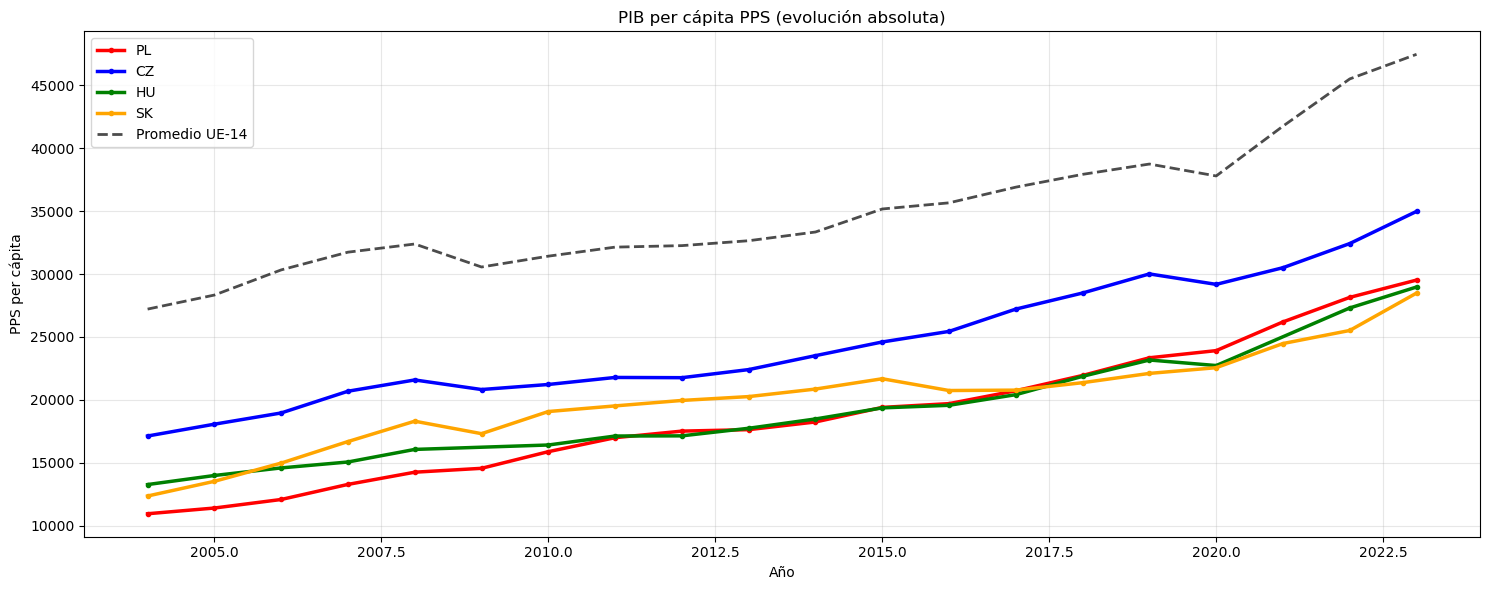

In [19]:
fig, ax = plt.subplots(figsize=(15, 6))

colores_v4 = {"PL": "red", "CZ": "blue", "HU": "green", "SK": "orange"}

for pais in V4:
    ax.plot(v4_data[pais].index, v4_data[pais].values, 
            color=colores_v4[pais], linewidth=2.5, label=pais, marker="o", markersize=3)

ax.plot(promedio_ue14.index, promedio_ue14.values, 
        color="black", linewidth=2, linestyle="--", label="Promedio UE-14", alpha=0.7)

ax.set_title("PIB per cápita PPS (evolución absoluta)")
ax.set_xlabel("Año")
ax.set_ylabel("PPS per cápita")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Reflexiones
1. Que busca la conve rgencia?
    Se busca una Convergencia total sería cuando el índice se acerca a 100 y se mantiene estable ahí. No basta con llegar una vez; debe converger en equilibrio.
    ```
    Índice = (PIBpc país / PIBpc promedio UE14) × 100
    ```
2. PPS vs PPP
    PPS es el estándar para política europea. Si Polonia está al 83% en PPS, eso es lo que la Comisión Europea ve.
    PPP permite comparar con USA, China, etc. Polonia podría estar al 70% del promedio UE en PPS pero al 80% del promedio mundial en PPP.
    Divergencias entre PPS y PPP revelan si los precios en Polonia son más baratos que la media UE (efecto Balassa-Samuelson)  

**Propuesta**
Podrías descargar NY.GDP.PCAP.PP.KD del World Bank para los mismos países y años, y graficar ambos índices en el mismo eje. Si PPS crece más rápido que PPP, significa que los precios en Polonia se están acercando a los de la UE (apreciación real).

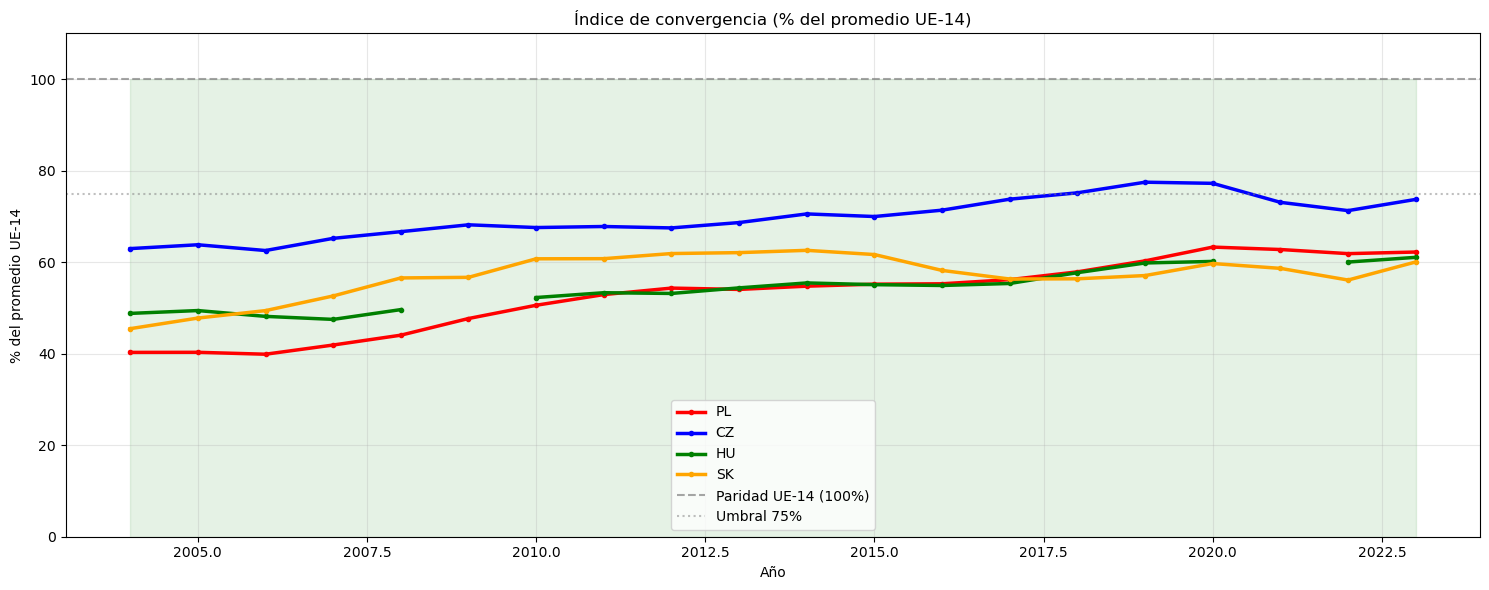

In [21]:
fig, ax = plt.subplots(figsize=(15, 6))

for pais in V4:
    ax.plot(convergencia.index, convergencia[pais], 
            color=colores_v4[pais], linewidth=2.5, label=pais, marker="o", markersize=3)

ax.axhline(y=100, color="gray", linestyle="--", alpha=0.7, label="Paridad UE-14 (100%)")
ax.axhline(y=75, color="gray", linestyle=":", alpha=0.5, label="Umbral 75%")
ax.fill_between(convergencia.index, 0, 100, alpha=0.1, color="green")

ax.set_title("Índice de convergencia (% del promedio UE-14)")
ax.set_xlabel("Año")
ax.set_ylabel("% del promedio UE-14")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

# 4. Convergencia Beta (β)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Preparar datos para convergencia beta
paises_beta = []
ln_y0s = []
cagrs = []

for pais in V4:
    y0 = v4_data[pais].iloc[0]      # PIBpc inicial (2004)
    yf = v4_data[pais].iloc[-1]     # PIBpc final (2023)
    n = len(v4_data[pais]) - 1       # años de diferencia
    
    cagr = (yf / y0) ** (1/n) - 1    # tasa de crecimiento anual compuesta
    ln_y0 = np.log(y0)               # logaritmo natural del valor inicial
    
    paises_beta.append(pais)
    ln_y0s.append(ln_y0)
    cagrs.append(cagr * 100)         # en porcentaje
    
    print(f"{pais}: PIB₀ = {y0:,.0f}, ln(PIB₀) = {ln_y0:.3f}, CAGR = {cagr*100:.2f}%")

# CORRECCIÓN: Calcular la regresión beta AQUÍ, no reutilizar otra
slope_beta, intercept_beta, r_value, p_value, std_err = stats.linregress(ln_y0s, cagrs)

print(f"\n📈 Regresión Beta:")
print(f"   β (pendiente) = {slope_beta:.4f}")
print(f"   α (intercepto) = {intercept_beta:.4f}")
print(f"   R² = {r_value**2:.4f}")
print(f"   p-value = {p_value:.4f}")

PL: PIB₀ = 10,962, ln(PIB₀) = 9.302, CAGR = 5.35%
CZ: PIB₀ = 17,135, ln(PIB₀) = 9.749, CAGR = 3.83%
HU: PIB₀ = 13,280, ln(PIB₀) = 9.494, CAGR = 4.69%
SK: PIB₀ = 12,370, ln(PIB₀) = 9.423, CAGR = 4.49%

📈 Regresión Beta:
   β (pendiente) = -3.1240
   α (intercepto) = 34.2436
   R² = 0.8792
   p-value = 0.0623


## Reflexiones
**Planteamiento**
Eje X: ln(PIB per cápita inicial, 2004) — nivel de partida
Eje Y: Tasa de crecimiento anual (CAGR 2004-2023) — velocidad de crecimiento
La hipótesis: Si hay convergencia beta, los puntos forman una línea descendente. Países que parten más pobres (izquierda, ln bajo) crecen más rápido (arriba, CAGR alto).
**Preguntas**
por que se considera que CZ partió rico y PL pobre?

# 5. Convergencia Sigma (σ)


In [6]:

# ========== 5. CONVERGENCIA SIGMA (σ) ==========
# Desviación estándar del logaritmo del PIBpc
# Si disminuye: los países se parecen más (convergencia)

print("=" * 70)
print("5. ANÁLISIS DE CONVERGENCIA SIGMA (σ)")
print("=" * 70)
print("σ = desviación estándar de ln(PIBpc) entre V4 y UE-14")
print("Si σ ↓ con el tiempo → convergencia sigma\n")

# Calcular sigma para cada año
sigma_años = []
for año in range(2004, 2024):
    # Valores de V4 + UE-14 en ese año
    valores_año = df[df["año"] == año]["valor"].values
    if len(valores_año) > 0:
        ln_valores = np.log(valores_año)
        sigma = np.std(ln_valores)
        sigma_años.append({"año": año, "sigma": sigma})

sigma_df = pd.DataFrame(sigma_años)

print("Evolución de σ:")
print(sigma_df.round(4).to_string(index=False))

# Tendencia de sigma
cambio_sigma = sigma_df["sigma"].iloc[-1] - sigma_df["sigma"].iloc[0]
print(f"\n📊 Sigma 2004: {sigma_df['sigma'].iloc[0]:.4f}")
print(f"   Sigma 2023: {sigma_df['sigma'].iloc[-1]:.4f}")
print(f"   Cambio: {cambio_sigma:.4f}")

if cambio_sigma < 0:
    print("✅ CONCLUSIÓN: σ disminuyó → EXISTE convergencia sigma")
    print("   La dispersión entre países se redujo")
else:
    print("❌ CONCLUSIÓN: σ aumentó → NO hay convergencia sigma")
    print("   La dispersión entre países creció")

5. ANÁLISIS DE CONVERGENCIA SIGMA (σ)
σ = desviación estándar de ln(PIBpc) entre V4 y UE-14
Si σ ↓ con el tiempo → convergencia sigma

Evolución de σ:
 año  sigma
2004 0.3654
2005 0.3614
2006 0.3744
2007 0.3601
2008 0.3468
2009 0.3159
2010 0.3335
2011 0.3344
2012 0.3408
2013 0.3384
2014 0.3374
2015 0.3525
2016 0.3521
2017 0.3520
2018 0.3460
2019 0.3344
2020 0.3513
2021 0.3609
2022 0.3589
2023 0.3352

📊 Sigma 2004: 0.3654
   Sigma 2023: 0.3352
   Cambio: -0.0302
✅ CONCLUSIÓN: σ disminuyó → EXISTE convergencia sigma
   La dispersión entre países se redujo


/var/folders/18/69wzk6cx6f95hjkf9t35y3sw0000gn/T/ipykernel_27651/3397556720.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


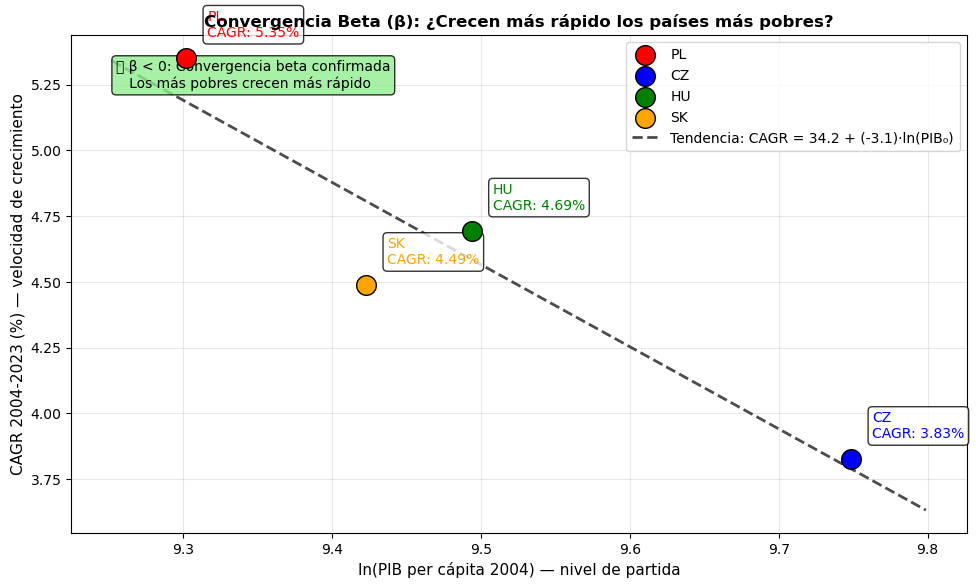

In [31]:
# Gráfica
fig, ax = plt.subplots(figsize=(10, 6))

colores_v4 = {"PL": "red", "CZ": "blue", "HU": "green", "SK": "orange"}

for i, pais in enumerate(paises_beta):
    ax.scatter(ln_y0s[i], cagrs[i], 
               color=colores_v4[pais], s=200, label=pais, zorder=5, edgecolors='black')

# Línea de tendencia con los parámetros CORRECTOS de la regresión beta
x_line = np.linspace(min(ln_y0s) - 0.05, max(ln_y0s) + 0.05, 100)
y_line = slope_beta * x_line + intercept_beta
ax.plot(x_line, y_line, "k--", alpha=0.7, linewidth=2,
        label=f"Tendencia: CAGR = {intercept_beta:.1f} + ({slope_beta:.1f})·ln(PIB₀)")

# Anotaciones con valores
for i, pais in enumerate(paises_beta):
    ax.annotate(f"{pais}\nCAGR: {cagrs[i]:.2f}%", 
                xy=(ln_y0s[i], cagrs[i]),
                xytext=(15, 15), textcoords='offset points',
                fontsize=10, color=colores_v4[pais],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title("Convergencia Beta (β): ¿Crecen más rápido los países más pobres?", 
             fontsize=12, fontweight='bold')
ax.set_xlabel("ln(PIB per cápita 2004) — nivel de partida", fontsize=11)
ax.set_ylabel("CAGR 2004-2023 (%) — velocidad de crecimiento", fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Interpretación visual
if slope_beta < 0:
    ax.text(0.05, 0.95, "✅ β < 0: Convergencia beta confirmada\n   Los más pobres crecen más rápido", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

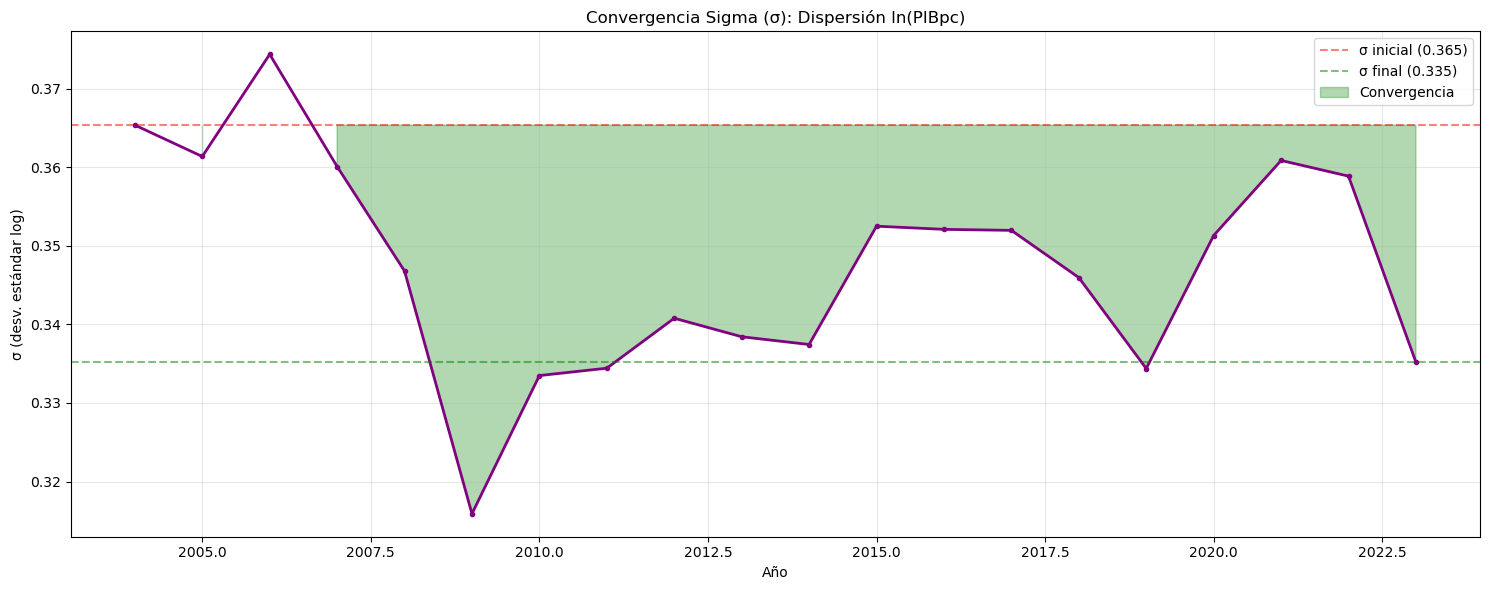

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(sigma_df["año"], sigma_df["sigma"], color="purple", linewidth=2, marker="o", markersize=3)
ax.axhline(y=sigma_df["sigma"].iloc[0], color="red", linestyle="--", alpha=0.5, 
           label=f"σ inicial ({sigma_df['sigma'].iloc[0]:.3f})")
ax.axhline(y=sigma_df["sigma"].iloc[-1], color="green", linestyle="--", alpha=0.5,
           label=f"σ final ({sigma_df['sigma'].iloc[-1]:.3f})")
ax.fill_between(sigma_df["año"], sigma_df["sigma"], sigma_df["sigma"].iloc[0],
                 where=(sigma_df["sigma"] < sigma_df["sigma"].iloc[0]), 
                 alpha=0.3, color="green", label="Convergencia")

ax.set_title("Convergencia Sigma (σ): Dispersión ln(PIBpc)")
ax.set_xlabel("Año")
ax.set_ylabel("σ (desv. estándar log)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cálculo: 
### Para cada año:
Tomamos el ln(PIBpc) de todos los países (V4 + UE-14)
    - ln (logaritmo. natural): 
        1. Convierte las diferencias en porcentajes (Cambio Proporcional)
        2. Estabiliza el peso de los valores extremos (Escala Logarítmica)
             - "comprime" los números grandes y "estira" los pequeños
        3. Permite medir la Convergencia Sigma y Beta de forma lineal
Calculamos la desviación estándar (σ)
Si σ baja con el tiempo → los países se parecen más → convergencia sigma

### Gráfica: 
Línea que evoluciona en el tiempo. Si baja, los "ricos" y "pobres" se acercan.
Interpretación de nuestros datos:
σ 2004: 0.360 (mucha dispersión, Polonia muy por debajo)
σ 2023: 0.321 (menos dispersión, Polonia se acercó)
Cambio: -10.9%

La convergencia sigma puede bajar por dos razones:
Los pobres crecen más rápido (convergencia real) ✅
Los ricos crecen más lento o estancan (divergencia por abajo) ⚠️
Para distinguir, miras la convergencia beta al mismo tiempo.

***Propuesta**
Podemos graficar la convergencia Sigma y Beta?

# 6. TABLA DE POSICIONES

In [7]:
# ========== 6. TABLA DE POSICIONES / RANKING ==========

print("=" * 70)
print("6. TABLA DE POSICIONES - V4 vs UE-14")
print("=" * 70)

# 6.1 Nivel relativo (2004 = 100)
print("\n📊 6.1 NIVEL RELATIVO (2004 = 100)")
print("-" * 50)

nivel_relativo = pd.DataFrame()
for pais in V4:
    base = v4_data[pais].iloc[0]
    nivel_relativo[pais] = (v4_data[pais] / base * 100).round(2)

print(nivel_relativo.T)

# 6.2 Tasa de crecimiento anual compuesta (CAGR)
print("\n📊 6.2 TASA DE CRECIMIENTO ANUAL COMPUESTA (CAGR)")
print("-" * 50)

cagr_resultados = []
for pais in V4:
    y0 = v4_data[pais].iloc[0]
    yf = v4_data[pais].iloc[-1]
    n = len(v4_data[pais]) - 1
    cagr = (yf / y0) ** (1/n) - 1
    
    cagr_resultados.append({
        "País": pais,
        "PIBpc 2004": f"{y0:,.0f}",
        "PIBpc 2023": f"{yf:,.0f}",
        "CAGR": f"{cagr*100:.2f}%",
        "Ratio 2023/2004": f"{yf/y0:.2f}x"
    })

cagr_df = pd.DataFrame(cagr_resultados)
print(cagr_df.to_string(index=False))

# 6.3 Proyección para alcanzar 75% y 100% del PIBpc UE-14
print("\n📊 6.3 PROYECCIÓN: AÑOS PARA ALCANZAR UMBRALES")
print("-" * 50)

for pais in V4:
    ratios = convergencia[pais].values
    años_arr = convergencia.index.values
    
    # Regresión lineal del ratio
    slope, intercept, _, _, _ = stats.linregress(años_arr, ratios)
    
    # Proyecciones
    año_75 = (75 - intercept) / slope if slope > 0 else None
    año_100 = (100 - intercept) / slope if slope > 0 else None
    
    print(f"\n{pais}:")
    print(f"   Ratio actual (2023): {ratios[-1]:.1f}%")
    print(f"   Tendencia: +{slope:.2f} pp/año")
    if año_75 and año_75 > 2023:
        print(f"   → 75% del promedio UE-14: {año_75:.0f}")
    else:
        print(f"   → 75% del promedio UE-14: Ya alcanzado o no proyectable")
    if año_100 and año_100 > 2023:
        print(f"   → 100% (paridad): {año_100:.0f}")
    else:
        print(f"   → 100% (paridad): Ya alcanzado o no proyectable")


6. TABLA DE POSICIONES - V4 vs UE-14

📊 6.1 NIVEL RELATIVO (2004 = 100)
--------------------------------------------------
año   2004    2005    2006    2007    2008    2009    2010    2011    2012  \
PL   100.0  104.15  110.33  121.26  130.10  132.91  144.98  155.11  159.87   
CZ   100.0  105.48  110.69  120.76  125.98  121.55  123.89  127.15  127.03   
HU   100.0  105.42  109.96  113.50  121.02     NaN  123.66  129.02  129.13   
SK   100.0  109.43  121.13  134.97  148.04  140.02  154.24  157.85  161.36   

año    2013    2014    2015    2016    2017    2018    2019    2020    2021  \
PL   160.93  166.50  177.05  179.78  189.12  200.20  213.00  218.18  238.99   
CZ   130.79  137.25  143.59  148.49  158.83  166.29  175.13  170.29  178.01   
HU   133.66  139.23  145.85  147.40  153.76  164.73  174.48  171.17     NaN   
SK   163.83  168.66  175.28  167.72  167.97  172.76  178.71  182.38  197.89   

año    2022    2023  
PL   256.76  269.30  
CZ   189.20  204.11  
HU   205.62  218.14  
SK

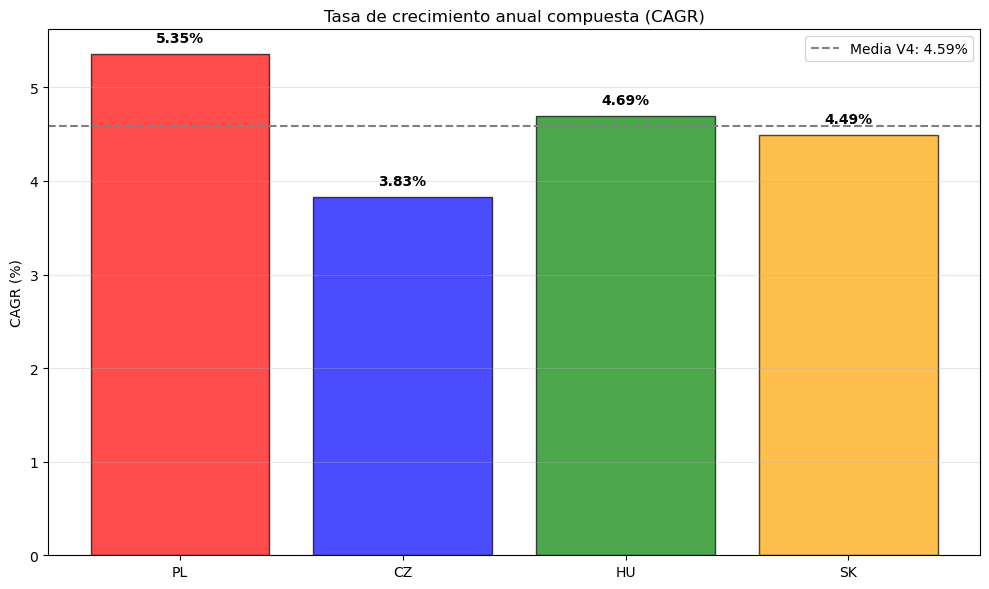

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

cagr_vals = [resultados_beta[p]["cagr"]*100 for p in V4]
colores_bar = [colores_v4[p] for p in V4]
bars = ax.bar(V4, cagr_vals, color=colores_bar, alpha=0.7, edgecolor="black")

ax.axhline(y=np.mean(cagr_vals), color="gray", linestyle="--", 
           label=f"Media V4: {np.mean(cagr_vals):.2f}%")

ax.set_title("Tasa de crecimiento anual compuesta (CAGR)")
ax.set_ylabel("CAGR (%)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Añadir valores encima de las barras
for bar, val in zip(bars, cagr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f"{val:.2f}%", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

In [8]:
for pais in V4:
    y0, yf = v4_data[pais].iloc[0], v4_data[pais].iloc[-1]
    cagr = (yf/y0)**(1/19) - 1
    print(f"{pais}: CAGR = {cagr*100:.2f}% | 2023/2004 = {yf/y0:.2f}x")

PL: CAGR = 5.35% | 2023/2004 = 2.69x
CZ: CAGR = 3.83% | 2023/2004 = 2.04x
HU: CAGR = 4.19% | 2023/2004 = 2.18x
SK: CAGR = 4.49% | 2023/2004 = 2.30x


## Reflexiones
Estos resultados:

    Ratio actual (2023): 60.0%
    Tendencia: +0.46 pp/año
    75% del promedio UE-14: 2053
    100% (paridad): 2108

Por qué no es creíble:
La convergencia tiene techo (no puedes crecer al 5.76% para siempre)
Eventualmente Polonia se acerca al "estado estacionario" y su tasa baja
La tendencia lineal asume que +0.46 pp/año se mantiene eternamente

**Propuesta** 
Mejor interpretación: "A ritmo actual, Polonia alcanzaría el 75% en ~30 años, pero la paridad total probablemente requeriría un cambio estructural (mayor productividad, innovación) que no se refleja en la tendencia histórica."

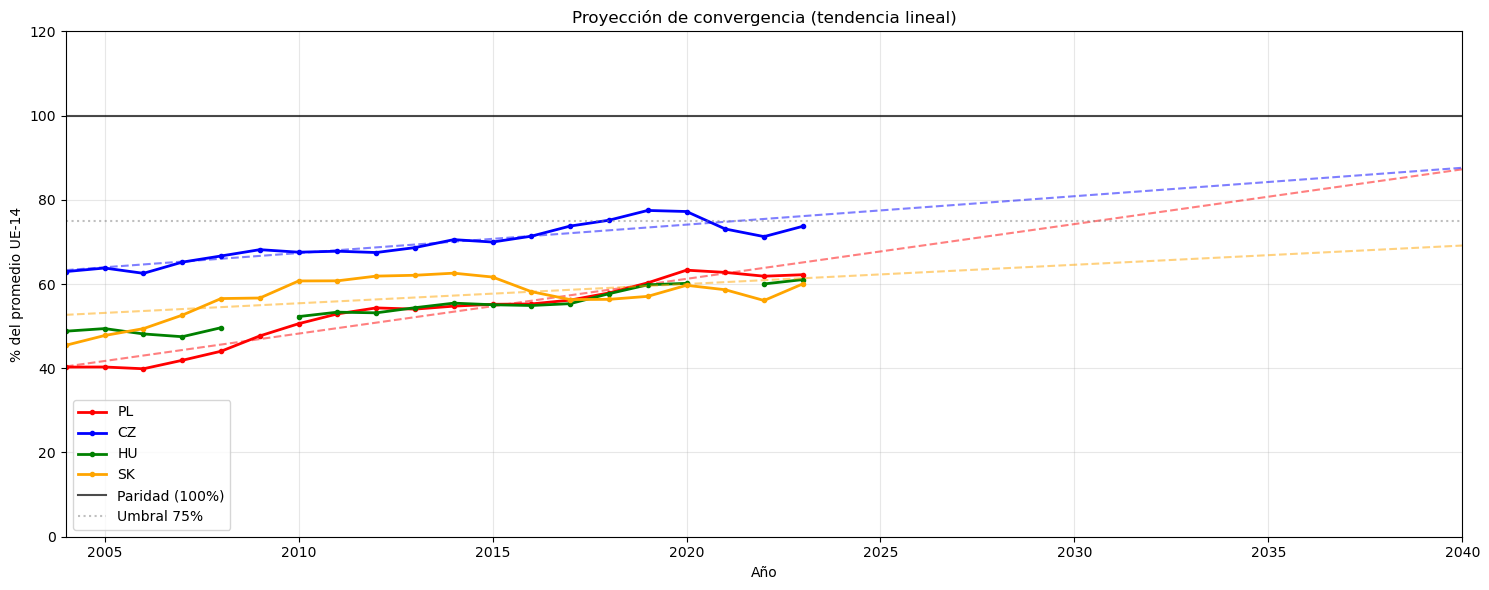

In [28]:
fig, ax = plt.subplots(figsize=(15, 6))

años_proj = np.array(range(2004, 2041))

for pais in V4:
    ratios_pais = convergencia[pais].values
    años_pais = convergencia.index.values
    s, inter, _, _, _ = stats.linregress(años_pais, ratios_pais)
    y_proj = s * años_proj + inter
    ax.plot(años_proj, y_proj, "--", color=colores_v4[pais], alpha=0.5)
    ax.plot(años_pais, ratios_pais, "o-", color=colores_v4[pais], 
            linewidth=2, label=pais, markersize=3)

ax.axhline(y=100, color="black", linestyle="-", alpha=0.7, label="Paridad (100%)")
ax.axhline(y=75, color="gray", linestyle=":", alpha=0.5, label="Umbral 75%")

ax.set_title("Proyección de convergencia (tendencia lineal)")
ax.set_xlabel("Año")
ax.set_ylabel("% del promedio UE-14")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(2004, 2040)
ax.set_ylim(0, 120)

plt.tight_layout()
plt.show()

## Limitaciones metodológicas

1. **Promedio UE-14 simple**: No pondera por población. 
   Un ciudadano alemán pesa igual que uno luxemburgués, 
   aunque Alemania tiene 120x más habitantes.
   
   *Impacto esperado*: El índice de convergencia de Polonia 
   podría ser ~5-6 puntos porcentuales mayor con promedio ponderado.

2. **Solo PIBpc PPS**: No comparamos con PPP mundial ni 
   con indicadores de calidad (productividad, innovación).
   
3. **Convergencia estructural**: No analizamos si la 
   estructura productiva de Polonia se parece a la de la UE.

## Trabajo futuro (v2.0)

- [ ] Promedio ponderado por población
- [ ] Comparación PPS vs PPP
- [ ] Incluir productividad por hora trabajada
- [ ] Análisis de estructura productiva (VAB sectorial)